# Robustez de classificadores a distorções de imagens

* Coletar ao menos 10 imagens das seguintes 3 classes existentes no ImageNet: zebra, Granny Smith (maçã) e Lakeland Terrier. Podem ser imagens encontradas em buscadores de internet.
* Analisar a qualidade da classificação do modelo convnextv2_tiny em função de parâmetros de distorção das transformações especificadas abaixo
* Considerar diversos graus de distorção. Estudar os limites do modelo, isto é, em que ponto o modelo passa a errar
* Usar as bibliotecas timm e AlbumentationsX como indicado abaixo

Transformações a serem testadas, e parâmetros a variar:

* OpticalDistortion: distort_range
* GaussianBlur: sigma_range
* MotionBlur: blur_range. Fixar direction_range = [0.0, 0.0] e allow_shifted = False
* RandomGamma: gamma_range
* RandomBrightnessContrast: brightness_range e contrast_range
* Downscale: scale_range
* ImageCompression: quality_range

## Códigos de exemplo

In [12]:
import albumentations as alb
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

img = Image.open("zebra.png")
# Classe correta da imagem. Precisa ser uma das classes do ImageNet
true_class = "zebra"

# Carrega as classes do ImageNet, como mostrado nos notebooks da disciplina
classes = open("imagenet_classes.txt").read().splitlines()

Exemplo de transformação

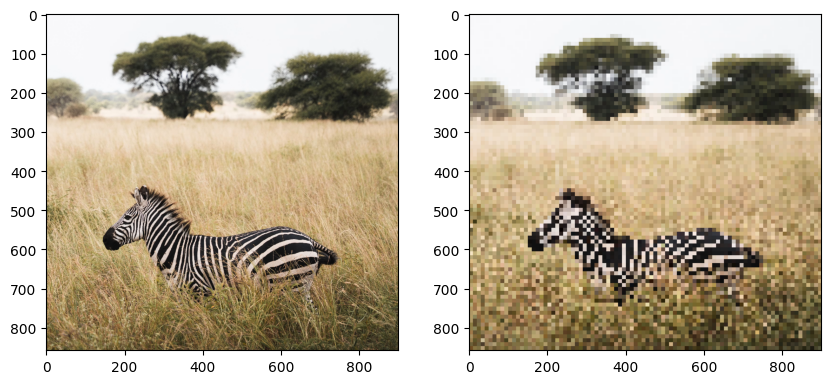

In [13]:
# Aplica a transformação de downscale. A imagem é reduzida para 10% do seu tamanho original,
# e em seguida é redimensionada de volta para o tamanho original, causando uma distorção.
# O parâmetro p=1.0 garante que a transformação seja aplicada com 100% de probabilidade.
# A função retorna um dicionário com a chave "image" contendo a imagem transformada.
img_t = alb.Downscale(scale_range=(0.1, 0.1), p=1.0)(image=np.array(img))["image"]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img)
axs[1].imshow(img_t)

In [14]:
def apply_transform(img, transform_dict):
    """Aplica uma transformação de distorção a uma imagem. 
    
    Parâmetros:
    img: 
        A imagem a ser transformada.
    transform_dict: 
        Um dicionário contendo a classe da transformação e seus parâmetros. O
        dicionário deve ter a seguinte estrutura:
        {
            "class": A classe da transformação a ser aplicada (ex: alb.Downscale),
            "parameters": Um dicionário contendo os parâmetros da transformação 
                (ex: {"scale_range": (0.1, 0.1)}),
        }

    Retorna:
        A imagem transformada.
    """

    img = np.array(img)
    transform = transform_dict["class"]
    parameters = transform_dict["parameters"]
    instance = transform(**parameters, p=1.0)

    return instance(image=img)["image"]

# Grau de distorção
val = 0.1

transform_dict = {
    # A classe de transformação a ser aplicada
    "class": alb.Downscale,
    # Parâmetros da transformação
    "parameters": {
        # Importante! O valor mínimo e máximo do parâmetro scale_range devem ser iguais para 
        # garantir um grau de distorção fixo.
        "scale_range": (val, val),
    },
}

img_t = apply_transform(img, transform_dict)

Extração das probabilidades de um modelo

In [15]:
import timm
import torch
from timm.data.transforms_factory import create_transform


def load_model(model_name):
    """Carrega a CNN pré-treinada e as classes do ImageNet a partir do nome de um modelo."""

    model = timm.create_model(model_name, pretrained=True)
    model.eval()
    
    data_config = timm.data.resolve_data_config(model=model)
    transforms = create_transform(**data_config)
    
    return model, transforms

def apply_model(img, model, transforms):
    """Aplica a CNN pré-treinada na imagem e retorna a predição do modelo."""

    img_t = transforms(img)
    batch = img_t.unsqueeze(0)

    with torch.inference_mode():
        output = model(batch)

    output = output[0]
    probs = torch.softmax(output, dim=0)
    
    return probs

def build_results(probs, classes, true_class):
    """Constrói um dicionário com os resultados da predição do modelo. Retorna a classe 
    verdadeira, a classe prevista e a segunda classe mais provável, junto com suas respectivas 
    probabilidades."""

    values, indices = torch.topk(probs, k=2)
    
    prob_true = probs[classes.index(true_class)].item()

    results = {
        "true_class": (true_class, prob_true),
        "predicted_class": (classes[indices[0]], values[0].item()),
        "second_predicted": (classes[indices[1]], values[1].item()),
    }

    return results

model, transforms = load_model("convnextv2_tiny")

In [17]:
probs = apply_model(img, model, transforms)
results = build_results(probs, classes, true_class)

results

{'true_class': ('zebra', 0.9307879209518433),
 'predicted_class': ('zebra', 0.9307879209518433),
 'second_predicted': ('hartebeest', 0.001106818439438939)}

A ideia é analisar a probabilidade de saída em função do grau de distorção:

![resultado](exemplo_resultado.png)